In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                           f1_score, precision_score, recall_score, 
                           accuracy_score, roc_auc_score, roc_curve)
from itertools import cycle
pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings('ignore')

# Creating SA dataset

The data used below was scraped from Property24 website on 24 January 2026. It consists of listed houses, apartments/flats and townhouses.

Data:

- Gauteng listings: 93_560
    - Collected: 73_227
    - Clean: 30_471

- Eastern Cape: 8_975
    - Collected: 8_754
    - Clean: 5_949

- Free State: 7_613
    - Collected: 7_557
    - Clean: 4_608

- Kwazulu-natal: 31_102 
    - Collected: 25_726
    - Clean: 11_038

- Limpopo: 4_153
    - Collected: 4_355
    - Clean: 2817

- Mpumalanga: 7_918
    - Collected: 7_964
    - Clean: 5218

- North West: 10_937
    - Collected: 10_536
    - Clean: 5770

- Northern Cape: 2_291
    - Collected: 2_403
    - Clean: 1749

- Western Cape: 20_325
    - Collected: 18_ 486
    - Clean: 9888

In [44]:
ec = pd.read_csv('Eastern_Cape_property_data.csv')
fs = pd.read_csv('Free_State_property_data.csv')
g = pd.read_csv('Gauteng_property_data.csv')
lm = pd.read_csv('Limpopo_property_data.csv')
kzn = pd.read_csv('KZN_property_data.csv') 
mp = pd.read_csv('Mpumalanga_property_data.csv')
nw = pd.read_csv('North_West_property_data.csv')
nc = pd.read_csv('Northern_Cape_property_data.csv')
wc = pd.read_csv('Western_Cape_property_data.csv')

provinces = [ec, fs, g, lm, kzn, mp, nw, nc, wc]

#adding province column
for province in provinces:
    if province.equals(ec):
        province['Province'] = 'Eastern Cape'
    elif province.equals(fs):
        province['Province'] = 'Free State'
    elif province.equals(g):
        province['Province'] = 'Gauteng'
    elif province.equals(lm):
        province['Province'] = 'Limpopo'
    elif province.equals(kzn):
        province['Province'] = 'KZN'
    elif province.equals(mp):
        province['Province'] = 'Mpumalanga'
    elif province.equals(nw):
        province['Province'] = 'North West'
    elif province.equals(nc):
        province['Province'] = 'Northern Cape'
    elif province.equals(wc):
        province['Province'] = 'Western Cape'
    else:
        print("Province not found")

#combining all provinces into one dataframe
south_africa_property_data = pd.concat(provinces, ignore_index=True)
south_africa_property_data.to_csv('South_Africa_property_data.csv', index=False)

# Clean SA data

In [45]:
sa_data_original = pd.read_csv('South_Africa_property_data.csv')
sa_data_working = sa_data_original.copy()

# remove unnecessary columns
sa_data_working = sa_data_working.drop(["Details_URL", "Title", "Location"], axis=1)

# remove duplicates
print(f"Original data shape: {sa_data_working.shape}")
sa_data_working.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {sa_data_working.shape}")

# removing unrealistic property prices
sa_data_working = sa_data_working[sa_data_working['Price'] >= 10000]
sa_data_working = sa_data_working[sa_data_working['Price'] < 200_000_000]
print(f"Data shape after removing unrealistic prices: {sa_data_working.shape}")

# modifying bed and bath figures(some figures include concatenated numbers, we want the first figure)
# If beds has three numbers (100 or more), remove the last digit
# sa_data_working.loc[sa_data_working['Beds'] >= 20, 'Beds'] //= 10

# If baths has three numbers, remove the last digit
# sa_data_working.loc[sa_data_working['Baths'] >= 20, 'Baths'] //= 10

# If garage is greater than 10, keep only the last digit
# sa_data_working.loc[sa_data_working['Garage'] == 100, 'Garage'] //= 10
# sa_data_working.loc[sa_data_working['Garage'] > 10, 'Garage'] %= 10

# addressing Nan values
sa_data_working['Beds'] = sa_data_working['Beds'].fillna(0)
sa_data_working['Baths'] = sa_data_working['Baths'].fillna(0)
sa_data_working['Garage'] = sa_data_working['Garage'].fillna(0)
sa_data_working['Price'] = sa_data_working['Price'].fillna(0)
sa_data_working = sa_data_working.dropna(how="all")
print(f"Data shape after dropping remaining NaN values: {sa_data_working.shape}")

# infer missing sqm using province average sqm
# calculation: sqm = price / avg price per sqm in the province
province_avg_price_per_sqm = sa_data_working.groupby('Province').apply(lambda x: (x['Price'] / x['Size_sqm']).mean())
def infer_sqm(row):
    if pd.isna(row['Size_sqm']) or row['Size_sqm'] == 0:
        avg_price_per_sqm = province_avg_price_per_sqm[row['Province']]
        inferred_sqm = row['Price'] / avg_price_per_sqm
        return inferred_sqm
    return row['Size_sqm']

sa_data_working['Size_sqm'] = sa_data_working.apply(infer_sqm, axis=1)

# remove price outliers
Q1 = sa_data_working['Price'].quantile(0.25)
Q3 = sa_data_working['Price'].quantile(0.75)
IQR = Q3 - Q1
sa_data_working = sa_data_working[(sa_data_working['Price'] >= Q1 - 1.5 * IQR) & (sa_data_working['Price'] <= Q3 + 1.5 * IQR)]

# remove size outliers
Q1_size = sa_data_working['Size_sqm'].quantile(0.25)
Q3_size = sa_data_working['Size_sqm'].quantile(0.75)
IQR_size = Q3_size - Q1_size
sa_data_working = sa_data_working[(sa_data_working['Size_sqm'] >= Q1_size - 1.5 * IQR_size) & (sa_data_working['Size_sqm'] <= Q3_size + 1.5 * IQR_size)]

# remove bed outliers
Q1_beds = sa_data_working['Beds'].quantile(0.25)
Q3_beds = sa_data_working['Beds'].quantile(0.75)
IQR_beds = Q3_beds - Q1_beds
sa_data_working = sa_data_working[(sa_data_working['Beds'] >= Q1_beds - 1.5 * IQR_beds) & (sa_data_working['Beds'] <= Q3_beds + 1.5 * IQR_beds)]

# remove bath outliers
Q1_baths = sa_data_working['Baths'].quantile(0.25)
Q3_baths = sa_data_working['Baths'].quantile(0.75)
IQR_baths = Q3_baths - Q1_baths
sa_data_working = sa_data_working[(sa_data_working['Baths'] >= Q1_baths - 1.5 * IQR_baths) & (sa_data_working['Baths'] <= Q3_baths + 1.5 * IQR_baths)]

# remove garage outliers
Q1_garage = sa_data_working['Garage'].quantile(0.25)
Q3_garage = sa_data_working['Garage'].quantile(0.75)
IQR_garage = Q3_garage - Q1_garage
sa_data_working = sa_data_working[(sa_data_working['Garage'] >= Q1_garage - 1.5 * IQR_garage) & (sa_data_working['Garage'] <= Q3_garage + 1.5 * IQR_garage)]

print(f"Final data shape outliers removed: {sa_data_working.shape}")

sa_data_working.to_csv('South_Africa_property_data_cleaned.csv', index=False)
sa_data_working.sort_values(by='Price', ascending=False)

Original data shape: (159008, 6)
Data shape after removing duplicates: (109097, 6)
Data shape after removing unrealistic prices: (108121, 6)
Data shape after dropping remaining NaN values: (108121, 6)
Final data shape outliers removed: (77508, 6)


,Price,Beds,Baths,Garage,Size_sqm,Province
97803,6125000.00,4.00,3.00,4.00,568.00,KZN
158188,6125000.00,2.00,1.00,2.00,201.00,Western Cape
99522,6110000.00,4.00,3.00,2.00,774.88,KZN
13060,6102688.00,5.00,3.00,4.00,1715.00,Free State
126630,6100000.00,3.00,2.00,1.00,138.55,Mpumalanga
...,...,...,...,...,...,...
146490,28000.00,2.00,2.00,0.00,1.48,Western Cape
142274,27500.00,1.00,1.00,0.00,1.46,Western Cape
155585,25000.00,1.00,1.00,1.00,1.32,Western Cape
155586,25000.00,1.00,1.00,0.00,1.32,Western Cape


# Descriptive Statistics

Provincial stats

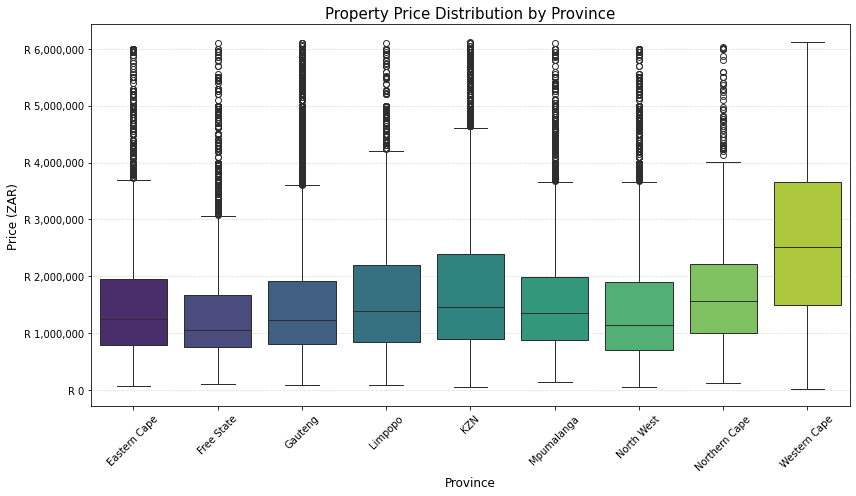

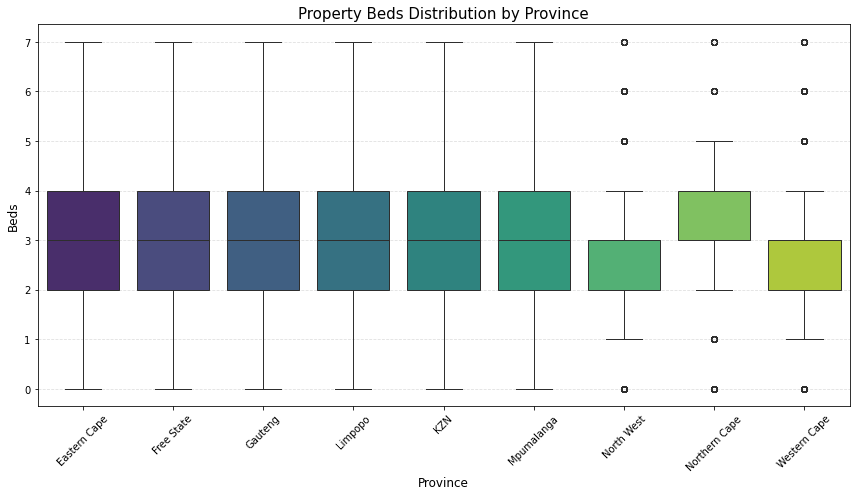

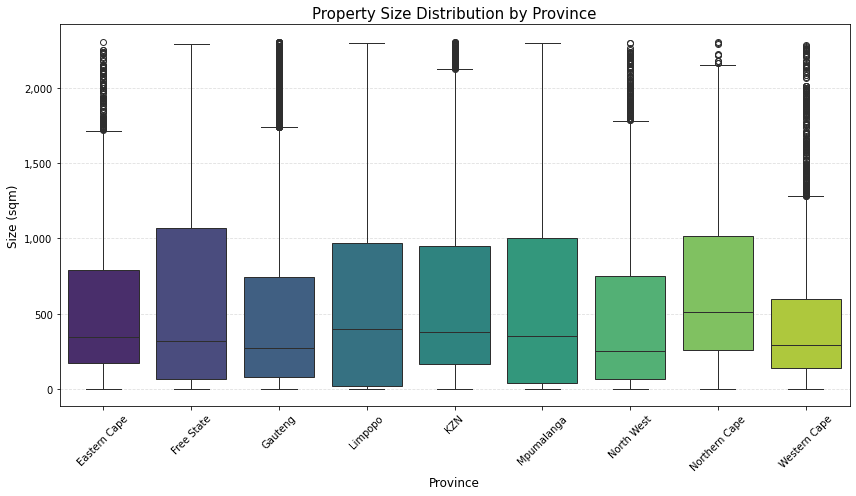

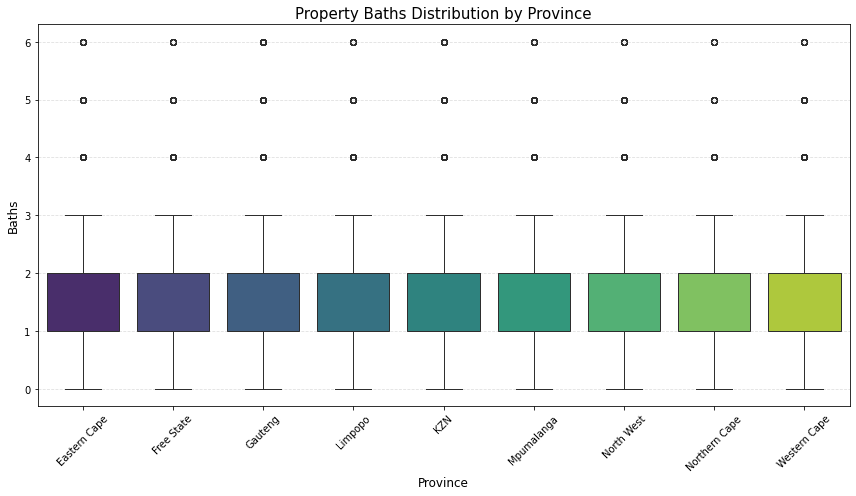

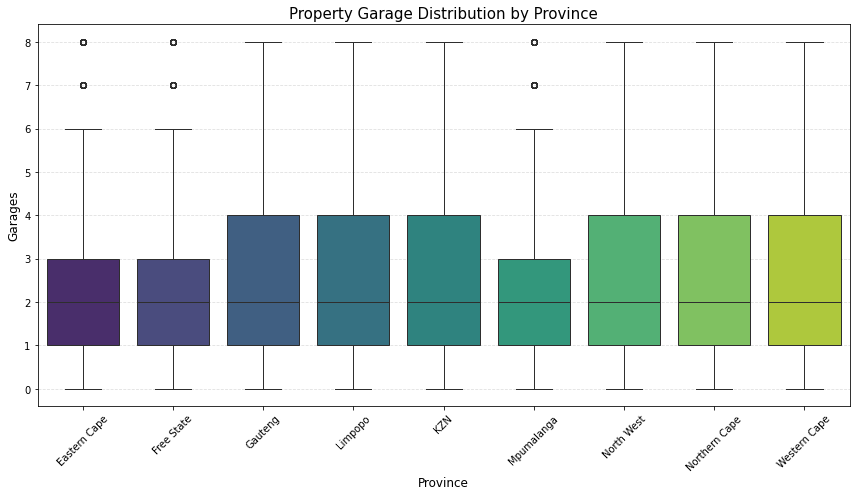

,Listings,Average Price,Average Size (sqm),Average Price per sqm,Average Bedrooms,Average Bathrooms,Average Garages
Province,,,,,,,
Eastern Cape,5949,1517247.16,515.93,5414.94,3.02,1.85,2.18
Free State,4608,1358238.47,586.54,14567.89,2.97,1.87,2.20
Gauteng,30471,1547290.69,457.69,14162.90,2.96,1.89,2.43
KZN,11038,1833197.16,596.62,7225.78,3.00,1.99,2.46
Limpopo,2817,1665654.08,572.80,63700.49,3.01,2.03,2.35
Mpumalanga,5218,1589622.45,580.92,30772.72,3.08,2.03,2.25
North West,5770,1479229.87,473.69,10098.40,2.88,1.90,2.45
Northern Cape,1749,1760825.20,666.43,10074.61,3.04,1.91,2.44
Western Cape,9888,2667072.99,410.31,11349.08,2.86,1.90,2.43


,Listings,Average Price,Average Size (sqm),Average Price per sqm,Average Bedrooms,Average Bathrooms,Average Garages
count,9.00,9.00,9.00,9.00,9.00,9.00,9.00
mean,8612.00,1713153.12,540.10,18596.31,2.98,1.93,2.35
std,8723.04,385800.51,81.15,18435.46,0.07,0.07,0.11
min,1749.00,1358238.47,410.31,5414.94,2.86,1.85,2.18
25%,4608.00,1517247.16,473.69,10074.61,2.96,1.89,2.25
50%,5770.00,1589622.45,572.80,11349.08,3.00,1.90,2.43
75%,9888.00,1760825.20,586.54,14567.89,3.02,1.99,2.44
max,30471.00,2667072.99,666.43,63700.49,3.08,2.03,2.46


In [46]:
clean_data = pd.read_csv('South_Africa_property_data_cleaned.csv')

# plot price distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Price', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Price Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Price (ZAR)', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: 'R {:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot bed distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Beds', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Beds Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Beds', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot size distribution
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Size_sqm', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Size Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Size (sqm)', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot bath distrinutions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Baths', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Baths Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Baths', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot garage distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Garage', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Garage Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Garages', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
listings_per_province = clean_data['Province'].value_counts()
average_price_per_province = clean_data.groupby('Province')['Price'].mean()
average_size_per_province = clean_data.groupby('Province')['Size_sqm'].mean()
average_price_per_sqm = clean_data.groupby('Province').apply(lambda x: (x['Price'] / x['Size_sqm']).mean())
average_bedrooms_per_province = clean_data.groupby('Province')['Beds'].mean()
average_bathrooms_per_province = clean_data.groupby('Province')['Baths'].mean()
average_garages_per_province = clean_data.groupby('Province')['Garage'].mean()

summary_df = pd.DataFrame({
    'Listings': listings_per_province,
    'Average Price': average_price_per_province,
    'Average Size (sqm)': average_size_per_province,
    'Average Price per sqm': average_price_per_sqm,
    'Average Bedrooms': average_bedrooms_per_province,
    'Average Bathrooms': average_bathrooms_per_province,
    'Average Garages': average_garages_per_province
})

display(summary_df.head(9))
display(summary_df.describe())

# Data Analysis

# - linear algebra stuff

In [ ]:
drop_province = clean_data.drop(['Province'], axis=1)
np_data =  drop_province.to_numpy()
mu = np.mean(np_data, axis=0)
sigma = np.std(np_data, axis=0)
normalized_data = (np_data - mu) / sigma

rank = np.linalg.matrix_rank(normalized_data) 

# feature importance 
cov_matrix = np.cov(normalized_data, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

feature_importance = eigenvalues / np.sum(eigenvalues)
for i, importance in enumerate(feature_importance):
    print(f"Principal Component {i+1}: {importance:.4f}")

# change of basis(aligning data along eigenspace)
# decouples the correlated features
pc_data = np.dot(normalized_data, eigenvectors)



Principal Component 1: 0.5268
Principal Component 2: 0.0576
Principal Component 3: 0.1534
Principal Component 4: 0.1346
Principal Component 5: 0.1276


# - Neural Network

DATA PREPROCESSING
Encoding province labels...
Number of unique provinces: 9
Training samples: 62006
Testing samples: 15502
Input dimension: 5
Output dimension (number of classes): 9

TRAINING WITH CROSSENTROPY LOSS
Epoch 1/20
  Train Loss: 1.7718, Train Acc: 41.58%
  Val Loss: 1.7080, Val Acc: 42.63%
  Val F1: 0.2920, Val Precision: 0.3071, Val Recall: 0.4263
Epoch 2/20
  Train Loss: 1.7212, Train Acc: 42.43%
  Val Loss: 1.6613, Val Acc: 43.10%
  Val F1: 0.3059, Val Precision: 0.2851, Val Recall: 0.4310
Epoch 3/20
  Train Loss: 1.6958, Train Acc: 42.90%
  Val Loss: 1.6301, Val Acc: 44.44%
  Val F1: 0.3329, Val Precision: 0.3509, Val Recall: 0.4444
Epoch 4/20
  Train Loss: 1.6779, Train Acc: 43.28%
  Val Loss: 1.6106, Val Acc: 43.90%
  Val F1: 0.3239, Val Precision: 0.3404, Val Recall: 0.4390
Epoch 5/20
  Train Loss: 1.6629, Train Acc: 43.71%
  Val Loss: 1.5902, Val Acc: 45.64%
  Val F1: 0.3523, Val Precision: 0.3634, Val Recall: 0.4564
Epoch 6/20
  Train Loss: 1.6540, Train Acc: 43.80

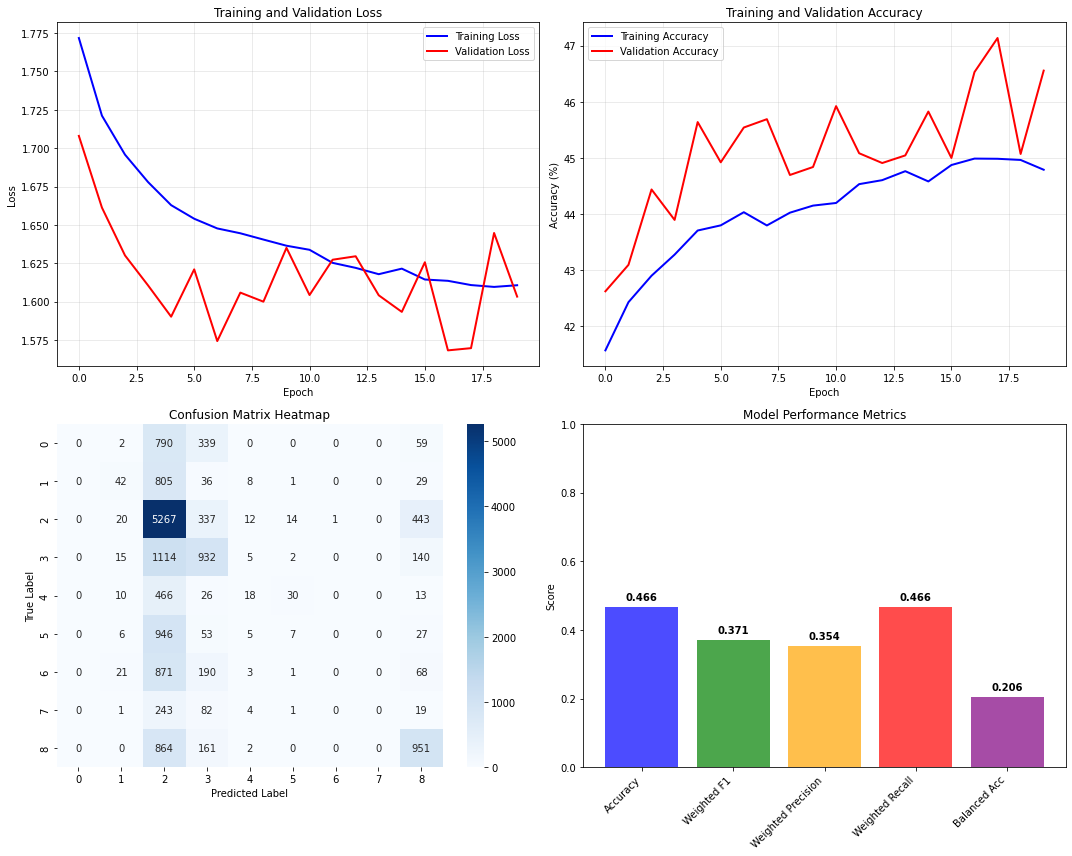


Visualization saved as 'model_evaluation_metrics.png'

MODEL PERFORMANCE SUMMARY
Best Validation Accuracy: 47.14%
Best Validation F1-Score: 0.3709
Final Model Performance on Test Set:
  - Accuracy: 0.4656
  - Weighted F1-Score: 0.3709
  - Cohen's Kappa: 0.2103
  - MCC: 0.2444


In [56]:
onehot_encoder = OneHotEncoder(sparse_output=False)
provinces_onehot = onehot_encoder.fit_transform(provinces.reshape(-1, 1))

# 1. Preprocessing and Data Preparation
print("=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# Check and encode provinces if needed
if isinstance(provinces[0], str) or isinstance(provinces[0], object):
    print("Encoding province labels...")
    le = LabelEncoder()
    provinces_encoded = le.fit_transform(provinces)
    num_classes = len(np.unique(provinces_encoded))
    print(f"Number of unique provinces: {num_classes}")
    
    # Save class names for reporting
    class_names = le.classes_
    
    # One-hot encode for MSE loss (or for probability outputs)
    onehot_encoder = OneHotEncoder(sparse_output=False)
    provinces_onehot = onehot_encoder.fit_transform(provinces_encoded.reshape(-1, 1))
    
    # For CrossEntropy loss, we'll use the encoded labels (not one-hot)
    y_for_ce = torch.tensor(provinces_encoded, dtype=torch.long)
    y_for_mse = torch.tensor(provinces_onehot, dtype=torch.float32)
    
else:
    # If already numerical
    num_classes = len(np.unique(provinces))
    print(f"Number of unique provinces: {num_classes}")
    
    if len(provinces.shape) == 2 and provinces.shape[1] > 1:
        # Already one-hot encoded
        provinces_onehot = provinces
        # Convert to class indices for CrossEntropy
        provinces_encoded = np.argmax(provinces, axis=1)
    else:
        # Label encoded
        provinces_encoded = provinces
        onehot_encoder = OneHotEncoder(sparse_output=False)
        provinces_onehot = onehot_encoder.fit_transform(provinces.reshape(-1, 1))
    
    class_names = [f"Class_{i}" for i in range(num_classes)]
    y_for_ce = torch.tensor(provinces_encoded, dtype=torch.long)
    y_for_mse = torch.tensor(provinces_onehot, dtype=torch.float32)

# Convert features to tensor
X_tensor = torch.tensor(pc_data, dtype=torch.float32)

# Split indices to maintain alignment
indices = list(range(len(pc_data)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=provinces_encoded)

# Split the data
X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
y_train_ce, y_test_ce = y_for_ce[train_idx], y_for_ce[test_idx]
y_train_mse, y_test_mse = y_for_mse[train_idx], y_for_mse[test_idx]

# Create datasets - we'll create two for different loss functions
train_dataset_ce = TensorDataset(X_train, y_train_ce)
test_dataset_ce = TensorDataset(X_test, y_test_ce)
train_dataset_mse = TensorDataset(X_train, y_train_mse)
test_dataset_mse = TensorDataset(X_test, y_test_mse)

# Create DataLoaders
train_loader_ce = DataLoader(train_dataset_ce, batch_size=32, shuffle=True)
test_loader_ce = DataLoader(test_dataset_ce, batch_size=32, shuffle=False)
train_loader_mse = DataLoader(train_dataset_mse, batch_size=32, shuffle=True)
test_loader_mse = DataLoader(test_dataset_mse, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_idx)}")
print(f"Testing samples: {len(test_idx)}")
print(f"Input dimension: {pc_data.shape[1]}")
print(f"Output dimension (number of classes): {num_classes}")

# 2. Model Definition
class RealEstateModel(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.fc4 = nn.Linear(32, output_dim)
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)  # Raw logits for CrossEntropyLoss
        return x

# 3. Training with CrossEntropy Loss (Better for Classification)
print("\n" + "=" * 50)
print("TRAINING WITH CROSSENTROPY LOSS")
print("=" * 50)

model_ce = RealEstateModel(input_dim=pc_data.shape[1], output_dim=num_classes)
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_ce = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ce, mode='min', patience=3, factor=0.5)
loss_fn_ce = nn.CrossEntropyLoss()

epochs = 20
train_losses_ce = []
val_losses_ce = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training phase
    model_ce.train()
    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader_ce:
        optimizer_ce.zero_grad()
        outputs = model_ce(inputs)
        loss = loss_fn_ce(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ce.parameters(), max_norm=1.0)
        optimizer_ce.step()
        
        epoch_train_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_ce)
    train_accuracy = 100 * correct_train / total_train
    train_losses_ce.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # Validation phase
    model_ce.eval()
    epoch_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader_ce:
            outputs = model_ce(inputs)
            loss = loss_fn_ce(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = epoch_val_loss / len(test_loader_ce)
    val_accuracy = 100 * correct_val / total_val
    val_losses_ce.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Update learning rate
    scheduler_ce.step(avg_val_loss)
    
    # Calculate F1 score for validation
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    val_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    val_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")
    print(f"  Val F1: {val_f1:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}")

# 4. Comprehensive Model Evaluation
print("\n" + "=" * 50)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

model_ce.eval()
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in test_loader_ce:
        outputs = model_ce(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probabilities = np.array(all_probabilities)

# 4.1 Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 50)
report = classification_report(all_true_labels, all_predictions, 
                              target_names=class_names if hasattr(class_names, '__len__') else None,
                              digits=4)
print(report)

# 4.2 Confusion Matrix
print("\n2. CONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(all_true_labels, all_predictions)
cm_df = pd.DataFrame(cm, 
                     index=class_names if hasattr(class_names, '__len__') else [f'Class {i}' for i in range(num_classes)],
                     columns=class_names if hasattr(class_names, '__len__') else [f'Class {i}' for i in range(num_classes)])

print("Confusion Matrix:")
print(cm_df)

# 4.3 Detailed Metrics by Class
print("\n3. DETAILED METRICS BY CLASS:")
print("-" * 50)
metrics_by_class = []
for i in range(num_classes):
    class_name = class_names[i] if hasattr(class_names, '__len__') else f'Class {i}'
    
    # Precision, Recall, F1 for this class
    precision = precision_score(all_true_labels == i, all_predictions == i, zero_division=0)
    recall = recall_score(all_true_labels == i, all_predictions == i, zero_division=0)
    f1 = f1_score(all_true_labels == i, all_predictions == i, zero_division=0)
    
    # Support (number of samples)
    support = np.sum(all_true_labels == i)
    
    metrics_by_class.append({
        'Class': class_name,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'Support': support
    })

metrics_df = pd.DataFrame(metrics_by_class)
print(metrics_df.to_string(index=False))

# 4.4 Overall Metrics
print("\n4. OVERALL METRICS:")
print("-" * 50)
accuracy = accuracy_score(all_true_labels, all_predictions)
macro_f1 = f1_score(all_true_labels, all_predictions, average='macro')
weighted_f1 = f1_score(all_true_labels, all_predictions, average='weighted')
macro_precision = precision_score(all_true_labels, all_predictions, average='macro', zero_division=0)
weighted_precision = precision_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
macro_recall = recall_score(all_true_labels, all_predictions, average='macro', zero_division=0)
weighted_recall = recall_score(all_true_labels, all_predictions, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")

# 4.5 ROC-AUC for multi-class (if 2 classes, use binary; if more, use one-vs-rest)
if num_classes == 2:
    # Binary classification
    roc_auc = roc_auc_score(all_true_labels, all_probabilities[:, 1])
    print(f"\nROC-AUC Score (Binary): {roc_auc:.4f}")
else:
    # Multi-class classification
    try:
        # One-vs-rest ROC AUC
        roc_auc_ovr = roc_auc_score(all_true_labels, all_probabilities, multi_class='ovr', average='weighted')
        print(f"\nROC-AUC Score (One-vs-Rest, weighted): {roc_auc_ovr:.4f}")
        
        # One-vs-one ROC AUC
        roc_auc_ovo = roc_auc_score(all_true_labels, all_probabilities, multi_class='ovo', average='weighted')
        print(f"ROC-AUC Score (One-vs-One, weighted): {roc_auc_ovo:.4f}")
    except:
        print("\nNote: ROC-AUC calculation requires probability estimates for all classes")

# 4.6 Additional Metrics
print("\n5. ADDITIONAL METRICS:")
print("-" * 50)
# Calculate Cohen's Kappa
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(all_true_labels, all_predictions)
print(f"Cohen's Kappa: {kappa:.4f}")

# Calculate Matthews Correlation Coefficient (good for imbalanced data)
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(all_true_labels, all_predictions)
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# Calculate Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(all_true_labels, all_predictions)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# 6. Visualization
print("\n" + "=" * 50)
print("VISUALIZATION")
print("=" * 50)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 6.1 Training History
ax1 = axes[0, 0]
ax1.plot(train_losses_ce, label='Training Loss', color='blue', linewidth=2)
ax1.plot(val_losses_ce, label='Validation Loss', color='red', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(train_accuracies, label='Training Accuracy', color='blue', linewidth=2)
ax2.plot(val_accuracies, label='Validation Accuracy', color='red', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 6.2 Confusion Matrix Heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(num_classes), 
            yticklabels=range(num_classes),
            ax=ax3)
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')
ax3.set_title('Confusion Matrix Heatmap')

# 6.3 Metrics Bar Chart
ax4 = axes[1, 1]
metrics_summary = {
    'Accuracy': accuracy,
    'Weighted F1': weighted_f1,
    'Weighted Precision': weighted_precision,
    'Weighted Recall': weighted_recall,
    'Balanced Acc': bal_acc
}
colors = ['blue', 'green', 'orange', 'red', 'purple']
ax4.bar(range(len(metrics_summary)), list(metrics_summary.values()), 
        color=colors, alpha=0.7)
ax4.set_xticks(range(len(metrics_summary)))
ax4.set_xticklabels(list(metrics_summary.keys()), rotation=45, ha='right')
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Metrics')
ax4.set_ylim([0, 1])
for i, v in enumerate(metrics_summary.values()):
    ax4.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'model_evaluation_metrics.png'")

# 7. Summary Report
print("\n" + "=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}%")
print(f"Best Validation F1-Score: {weighted_f1:.4f}")
print(f"Final Model Performance on Test Set:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Weighted F1-Score: {weighted_f1:.4f}")
print(f"  - Cohen's Kappa: {kappa:.4f}")
print(f"  - MCC: {mcc:.4f}")